<a href="https://colab.research.google.com/github/mathesh16012007-ship-it/HR-Employee-Attrition-Analysis/blob/main/HR_Employee_attrition_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Employee_ID,Department,Monthly_Salary,Years_Experience,Overtime
0,1001,R&D,9602,7,No
1,1002,Marketing,9812,14,No
2,1003,HR,7820,14,No
3,1004,R&D,8632,8,No
4,1005,Sales,10391,8,Yes


Missing Values Before Cleaning:
Employee_ID          0
Department           0
Monthly_Salary      20
Years_Experience    10
Overtime             0
Attrition            0
dtype: int64

Missing Values After Cleaning:
Employee_ID         0
Department          0
Monthly_Salary      0
Years_Experience    0
Overtime            0
Attrition           0
dtype: int64

================ OVERALL ATTRITION =================
Attrition
No     73.0
Yes    27.0
Name: proportion, dtype: float64

================ DEPARTMENT =================


Attrition,No,Yes
Department,,
HR,64.583333,35.416667
Marketing,70.754717,29.245283
R&D,72.916667,27.083333
Sales,77.272727,22.727273



================ SALARY TIER =================


Attrition,No,Yes
Salary_Tier,,
Low,54.255319,45.744681
Medium,77.419355,22.580645
High,77.248677,22.751323



================ EXPERIENCE TIER =================


Attrition,No,Yes
Experience_Tier,,
Junior,66.326531,33.673469
Mid,76.470588,23.529412
Senior,73.851590,26.148410



================ OVERTIME =================


Attrition,No,Yes
Overtime,,
No,81.981982,18.018018
Yes,55.089820,44.910180


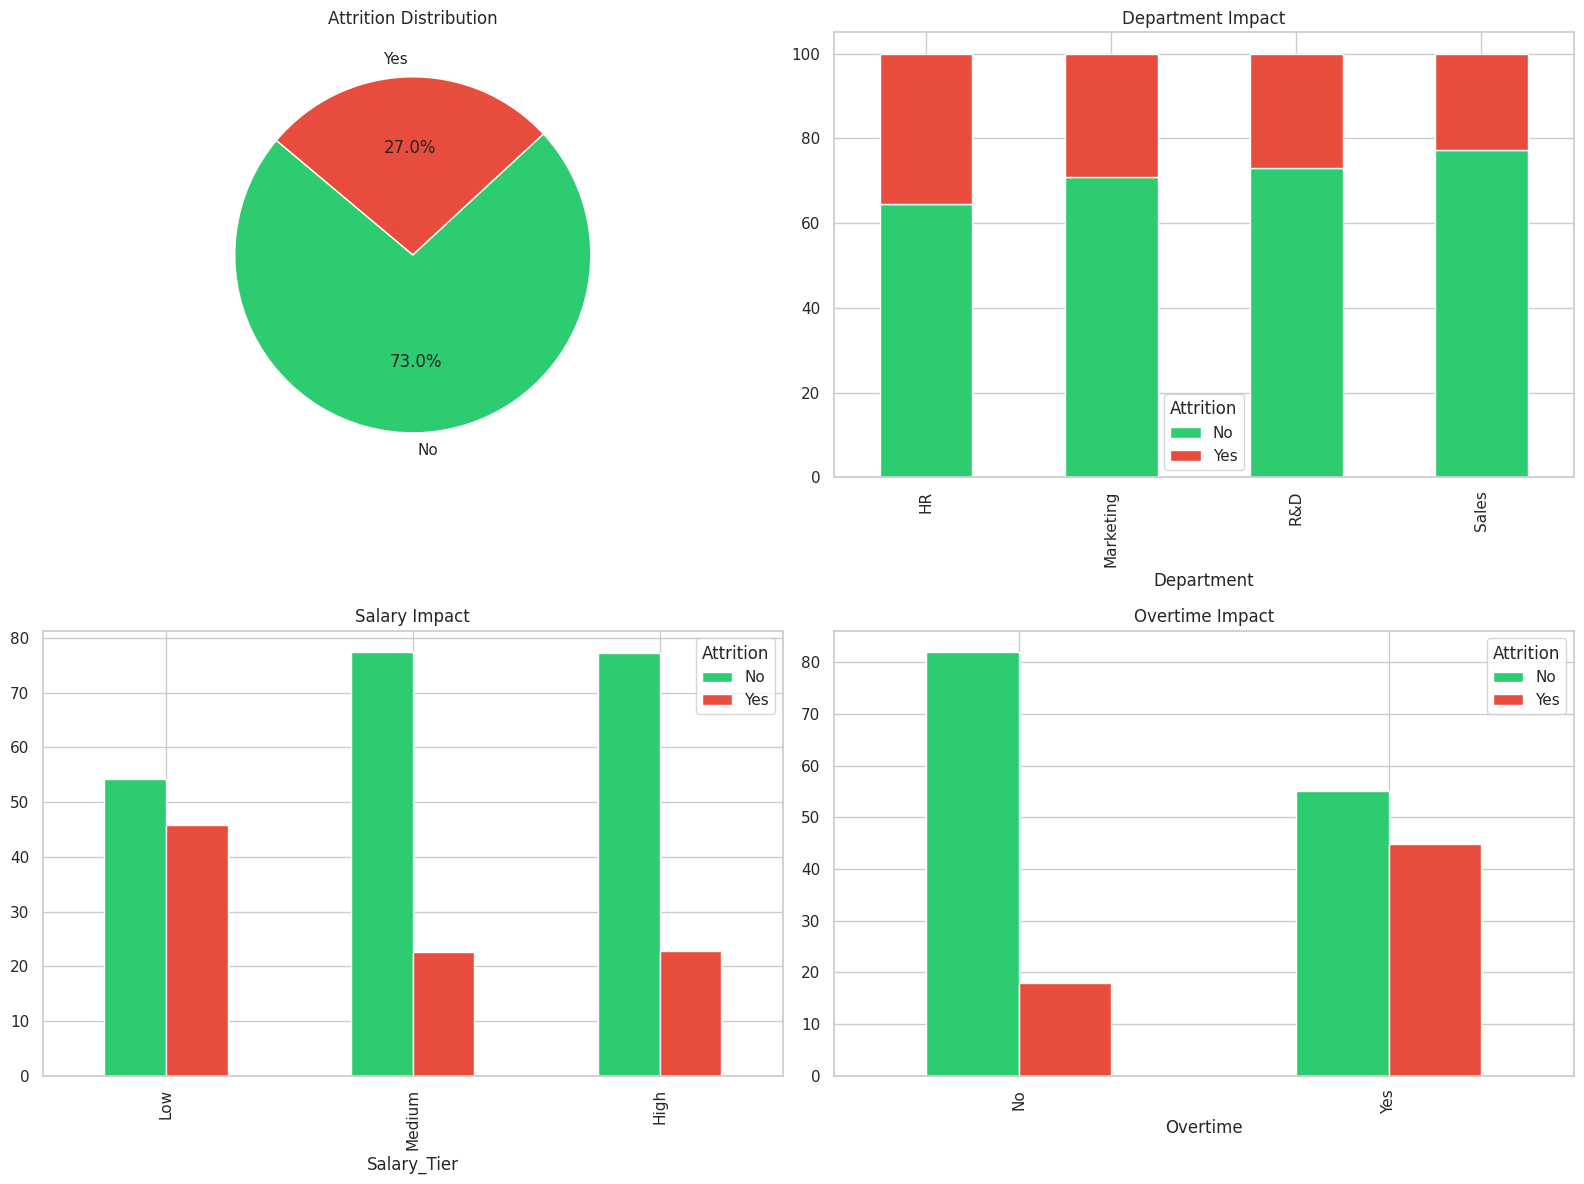

In [1]:

# ==========================================
# 1. IMPORT LIBRARIES + SETTINGS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

%matplotlib inline
sns.set_theme(style="whitegrid")


# ==========================================
# 2. CREATE DATASET
# ==========================================

np.random.seed(42)
n_employees = 500

df = pd.DataFrame({
    'Employee_ID': range(1001, 1001 + n_employees),
    'Department': np.random.choice(
        ['Sales', 'R&D', 'HR', 'Marketing'],
        n_employees,
        p=[0.3, 0.4, 0.1, 0.2]
    ),
    'Monthly_Salary': np.random.randint(2500, 15000, n_employees),
    'Years_Experience': np.random.randint(0, 20, n_employees),
    'Overtime': np.random.choice(['Yes', 'No'], n_employees, p=[0.35, 0.65])
})

display(df.head())


# ==========================================
# 3. CREATE ATTRITION LOGIC
# ==========================================

df['Attrition_Prob'] = 0.1
df.loc[df['Overtime'] == 'Yes', 'Attrition_Prob'] += 0.25
df.loc[df['Monthly_Salary'] < 5000, 'Attrition_Prob'] += 0.2
df.loc[df['Years_Experience'] < 3, 'Attrition_Prob'] += 0.15

df['Attrition'] = df['Attrition_Prob'].apply(
    lambda x: 'Yes' if np.random.rand() < x else 'No'
)

df.drop(columns=['Attrition_Prob'], inplace=True)


# ==========================================
# 4. ADD MISSING VALUES (REALISTIC DATA)
# ==========================================

df.loc[df.sample(frac=0.04).index, 'Monthly_Salary'] = np.nan
df.loc[df.sample(frac=0.02).index, 'Years_Experience'] = np.nan

print("Missing Values Before Cleaning:")
print(df.isnull().sum())


# ==========================================
# 5. DATA CLEANING
# ==========================================

df['Monthly_Salary'] = df['Monthly_Salary'].fillna(df['Monthly_Salary'].median())
df['Years_Experience'] = df['Years_Experience'].fillna(df['Years_Experience'].median())

df['Years_Experience'] = df['Years_Experience'].astype(int)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# ==========================================
# 6. ATTRITION ANALYSIS
# ==========================================

print("\n================ OVERALL ATTRITION =================")
print(df['Attrition'].value_counts(normalize=True) * 100)


print("\n================ DEPARTMENT =================")
dept_analysis = df.groupby('Department')['Attrition'].value_counts(normalize=True).unstack() * 100
display(dept_analysis)


print("\n================ SALARY TIER =================")
df['Salary_Tier'] = pd.cut(
    df['Monthly_Salary'],
    bins=[0, 5000, 10000, 20000],
    labels=['Low', 'Medium', 'High']
)

salary_analysis = (
    df.groupby('Salary_Tier', observed=True)['Attrition']
    .value_counts(normalize=True)
    .unstack() * 100
)
display(salary_analysis)


print("\n================ EXPERIENCE TIER =================")
df['Experience_Tier'] = pd.cut(
    df['Years_Experience'],
    bins=[-1, 3, 8, 25],
    labels=['Junior', 'Mid', 'Senior']
)

exp_analysis = (
    df.groupby('Experience_Tier', observed=True)['Attrition']
    .value_counts(normalize=True)
    .unstack() * 100
)
display(exp_analysis)


print("\n================ OVERTIME =================")
overtime_analysis = df.groupby('Overtime')['Attrition'].value_counts(normalize=True).unstack() * 100
display(overtime_analysis)


# ==========================================
# 7. VISUALIZATION DASHBOARD
# ==========================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---------------- PIE CHART ----------------
axes[0, 0].pie(
    df['Attrition'].value_counts(),
    labels=df['Attrition'].value_counts().index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=140
)
axes[0, 0].set_title("Attrition Distribution")

# ---------------- DEPARTMENT ----------------
dept_analysis.plot(kind='bar', stacked=True, ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title("Department Impact")

# ---------------- SALARY ----------------
salary_analysis.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title("Salary Impact")

# ---------------- OVERTIME ----------------
overtime_analysis.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title("Overtime Impact")

plt.tight_layout()
plt.show()